<a href="https://colab.research.google.com/github/Devaki465/MachineLearning/blob/main/DT_Housing_Price_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree Regression

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [ ]:
# ---------------------------
# 1) Load data
# ---------------------------
csv_path = "/content/HousingData_regression.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2



Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


In [ ]:
# ---------------------------
# 2) Choose target column
#    OPTION A (default): last column is target
#    OPTION B: manually set target_col = "your_target_name"
# ---------------------------
target_col = df.columns[-1]  # <-- change if needed, e.g. target_col = "price"
print("\nUsing target column:", target_col)


Using target column: MEDV


In [ ]:
# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

In [ ]:
# ---------------------------
# 3) Identify numeric/categorical columns
# ---------------------------
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("\nNumeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)


Numeric cols: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Categorical cols: []


In [ ]:
# ---------------------------
# 4) Preprocessing
#    - Numeric: median impute
#    - Categorical: most_frequent impute + OneHotEncode
# ---------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

In [ ]:
# ---------------------------
# 5) Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# ---------------------------
# 6) Baseline Decision Tree model
# ---------------------------
dt = DecisionTreeRegressor(random_state=42)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("dt", dt)
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n=== Baseline Decision Tree Results ===")
print("MAE :", mae)
print("RMSE:", rmse)
print("R^2 :", r2)



=== Baseline Decision Tree Results ===
MAE : 3.1529411764705877
RMSE: 5.112211447343795
R^2 : 0.6436198330963367


max_depth → How deep the tree can grow
min_samples_split → Minimum samples required to split a node
min_samples_leaf → Minimum samples required at a leaf node
max_features → Number of features considered at each split
**These are hyperparameters.**


"dt__max_depth": [None, 3, 5, 8, 12, 20] ->How deep the tree can grow (number of levels).
| Value  | Meaning      | Effect                                        |
| ------ | ------------ | --------------------------------------------- |
| `None` | No limit     | Tree grows until pure → high overfitting risk |
| `3`    | Max 3 levels | Very small tree → underfitting possible       |
| `5`    | Medium-small | Safer, less overfitting                       |
| `8`    | Moderate     | Good balance usually                          |
| `12`   | Deep         | More complex patterns                         |
| `20`   | Very deep    | High overfitting risk                         |



"dt__min_samples_split": [2, 5, 10, 20] --> Minimum number of samples required to split a node.
| Value | Meaning                 | Effect                  |
| ----- | ----------------------- | ----------------------- |
| `2`   | Default                 | Split whenever possible |
| `5`   | Need at least 5 samples | Fewer splits            |
| `10`  | Need 10 samples         | Tree becomes smaller    |
| `20`  | Need 20 samples         | Much more conservative  |


"dt__min_samples_leaf": [1, 2, 5, 10] --> Minimum number of samples required at a leaf node.
| Value | Meaning                     | Effect                   |
| ----- | --------------------------- | ------------------------ |
| `1`   | Default                     | Leaves can have 1 sample |
| `2`   | At least 2 samples per leaf | Slight smoothing         |
| `5`   | At least 5 samples          | Strong smoothing         |
| `10`  | At least 10 samples         | Very smooth tree         |


"dt__max_features": [None, "sqrt", "log2"]--> Number of features considered at each split.
| Value    | Meaning                   |
| -------- | ------------------------- |
| `None`   | Use all 16 features       |
| `"sqrt"` | Use √16 = 4 features      |
| `"log2"` | Use log₂(16) = 4 features |


| Parameter         | Controls           | Small Value     | Large Value   |
| ----------------- | ------------------ | --------------- | ------------- |
| max_depth         | Tree height        | Underfitting    | Overfitting   |
| min_samples_split | Split condition    | More splits     | Fewer splits  |
| min_samples_leaf  | Leaf size          | Noisy leaves    | Smooth leaves |
| max_features      | Features per split | More randomness | Greedy splits |


In [ ]:
# ---------------------------
# 7) Hyperparameter tuning
# ---------------------------
param_grid = {
    "dt__max_depth": [None, 3, 5, 8, 12, 20],
    "dt__min_samples_split": [2, 5, 10, 20],
    "dt__min_samples_leaf": [1, 2, 5, 10],
    "dt__max_features": [None, "sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

best_mae = mean_absolute_error(y_test, best_pred)
best_mse = mean_squared_error(y_test, best_pred)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, best_pred)

print("\n=== Best Model (GridSearchCV) ===")
print("Best Params:", grid.best_params_)
print("MAE :", best_mae)
print("RMSE:", best_rmse)
print("R^2 :", best_r2)



=== Best Model (GridSearchCV) ===
Best Params: {'dt__max_depth': 8, 'dt__max_features': None, 'dt__min_samples_leaf': 10, 'dt__min_samples_split': 2}
MAE : 2.705113527635458
RMSE: 4.116060318299338
R^2 : 0.7689747915113038


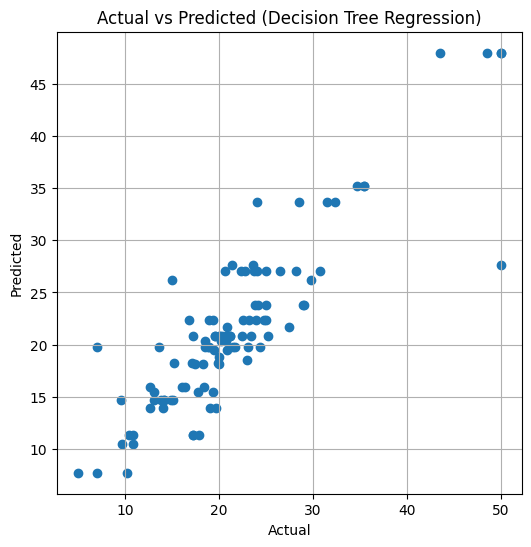

In [ ]:
# ---------------------------
# 8) Plot Actual vs Predicted
# ---------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Decision Tree Regression)")
plt.grid(True)
plt.show()

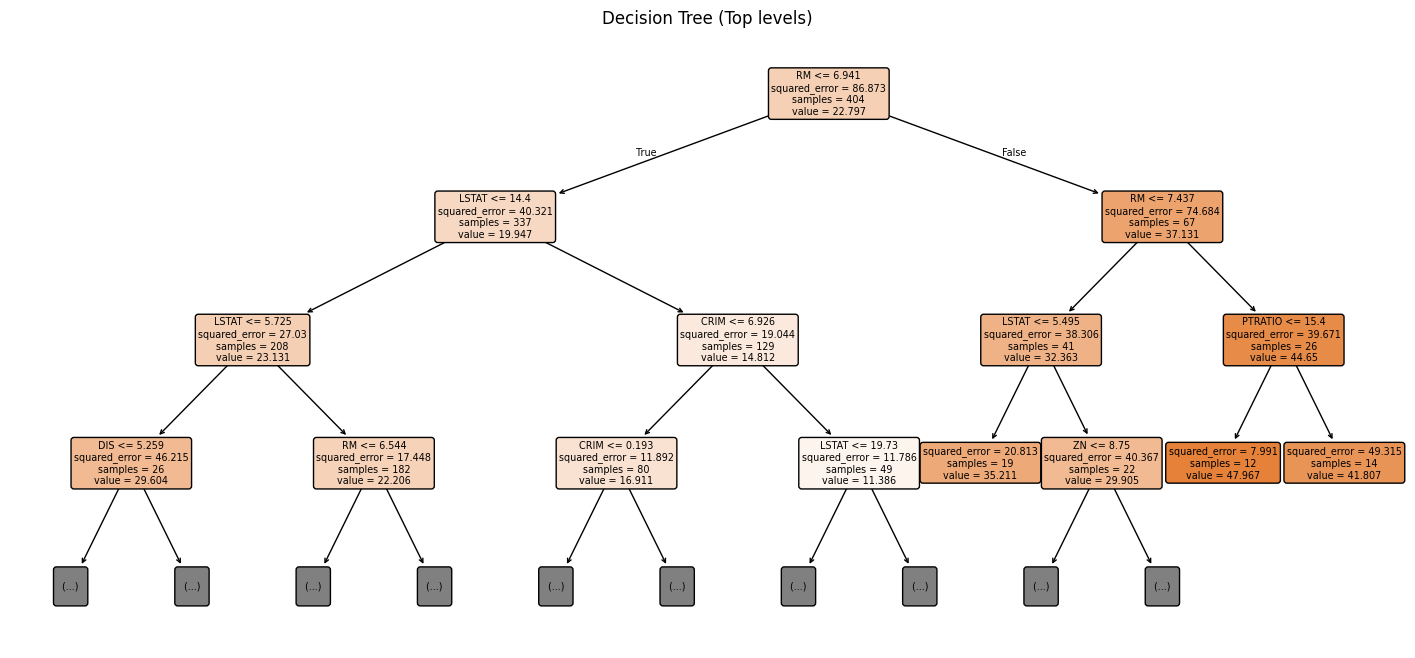

In [ ]:
# ---------------------------
# 9) Plot the decision tree (small depth for readability)
#    NOTE: After OneHotEncoding, feature names expand.
#          We'll plot a simplified tree by limiting depth.
# ---------------------------
# Extract trained tree regressor
trained_dt = best_model.named_steps["dt"]

# Create feature names after preprocessing
pre = best_model.named_steps["preprocess"]
feature_names = []

# numeric names
feature_names.extend(numeric_cols)

# categorical onehot names
if len(categorical_cols) > 0:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    ohe_names = ohe.get_feature_names_out(categorical_cols).tolist()
    feature_names.extend(ohe_names)

plt.figure(figsize=(18, 8))
plot_tree(
    trained_dt,
    feature_names=feature_names,
    filled=True,
    max_depth=3,          # keep readable; increase if you want
    rounded=True
)
plt.title("Decision Tree (Top levels)")
plt.show()

In [ ]:
# ---------------------------
# 10) Feature Importance (top 20)
# ---------------------------
importances = trained_dt.feature_importances_
idx = np.argsort(importances)[::-1][:20]

print("\nTop 20 Feature Importances:")
for i in idx:
    print(f"{feature_names[i]:<40} {importances[i]:.4f}")


Top 20 Feature Importances:
RM                                       0.6576
LSTAT                                    0.2591
CRIM                                     0.0432
ZN                                       0.0104
PTRATIO                                  0.0102
DIS                                      0.0090
NOX                                      0.0061
B                                        0.0045
TAX                                      0.0000
RAD                                      0.0000
AGE                                      0.0000
INDUS                                    0.0000
CHAS                                     0.0000


Residual Plot

If residuals randomly scattered → good model
Pattern → model missing something
Funnel shape → heteroscedasticity

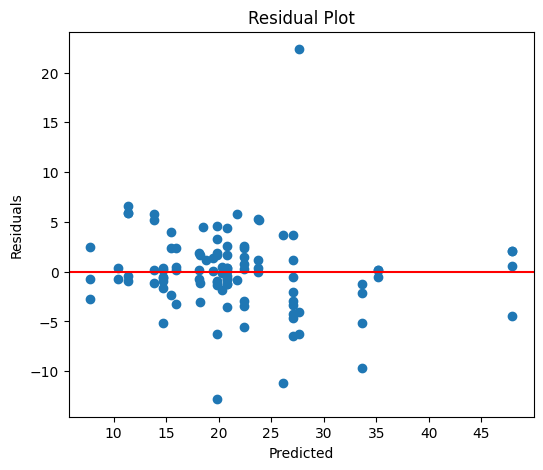

In [ ]:
residuals = y_test - best_pred

plt.figure(figsize=(6,5))
plt.scatter(best_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
